In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import chineseize_matplotlib  # 注册 SimHei，避免标题/坐标轴中文乱码

# 相对 notebook 位置定位 CSV，无论从哪里启动都能找到
LOG_PATH = os.path.join(os.path.dirname(os.path.abspath("log_watcher.ipynb")),
                        "logs", "train_log.csv")
print("读取：", LOG_PATH)

读取： /home/huanghao/KK/Orbit_War/scripts/v3_NN/logs/train_log.csv


已训练迭代：407，最新 iter=407


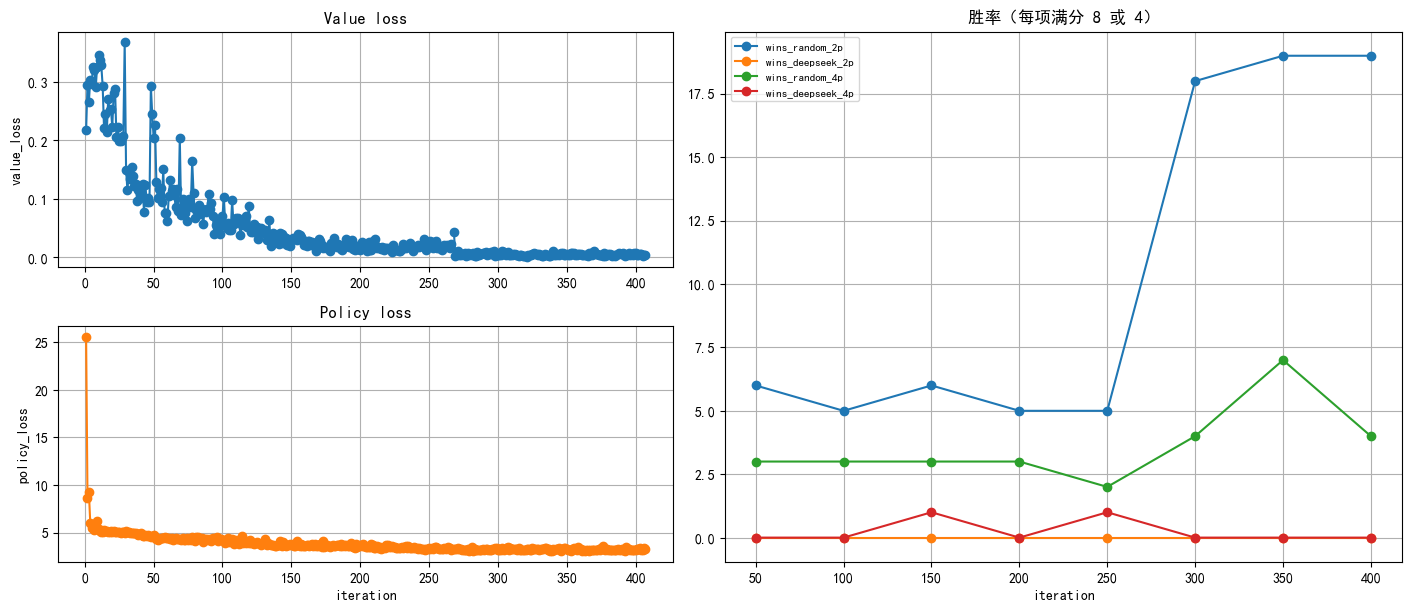

In [2]:
df = pd.read_csv(LOG_PATH)
print(f"已训练迭代：{len(df)}，最新 iter={df['iteration'].iloc[-1]}")

win_cols = [c for c in df.columns if c.startswith("wins_")]
eval_df = df.dropna(subset=win_cols[:1]).copy()

# 左：value / policy 分图（各自纵轴）；右：胜率
fig = plt.figure(figsize=(14, 6), layout="constrained")
gs = fig.add_gridspec(2, 2, width_ratios=[1, 1.1])
ax_v = fig.add_subplot(gs[0, 0])
ax_p = fig.add_subplot(gs[1, 0])
ax_w = fig.add_subplot(gs[:, 1])

x = df["iteration"]
ax_v.plot(x, df["value_loss"], color="C0", marker="o", label="value_loss")
ax_v.set_title("Value loss")
ax_v.set_ylabel("value_loss")
ax_v.grid(True)

ax_p.plot(x, df["policy_loss"], color="C1", marker="o", label="policy_loss")
ax_p.set_title("Policy loss")
ax_p.set_xlabel("iteration")
ax_p.set_ylabel("policy_loss")
ax_p.grid(True)

if not eval_df.empty:
    for col in win_cols:
        ax_w.plot(eval_df["iteration"], eval_df[col], marker="o", label=col)
    ax_w.set_title("胜率（每项满分 8 或 4）")
    ax_w.set_xlabel("iteration")
    ax_w.legend(fontsize=8)
    ax_w.grid(True)
else:
    ax_w.set_title("暂无评估数据（等到 iter 50）")

plt.show()

In [3]:
# 最近 5 条数字摘要
print(f"最近 value_loss ：{df['value_loss'].dropna().tail(5).values}")
print(f"最近 policy_loss：{df['policy_loss'].dropna().tail(5).values}")

win_cols = [c for c in df.columns if c.startswith("wins_")]
eval_df = df[df[win_cols[0]].notna()][["iteration"] + win_cols].tail(5) if win_cols else None
if eval_df is not None and not eval_df.empty:
    print("\n最近评估结果：")
    print(eval_df.to_string(index=False))

最近 value_loss ：[0.00672022 0.00605947 0.00310652 0.00402946 0.00399391]
最近 policy_loss：[3.40361309 3.23814631 3.14907479 3.38076758 3.26072788]

最近评估结果：
 iteration  wins_random_2p  wins_deepseek_2p  wins_random_4p  wins_deepseek_4p
       200             5.0               0.0             3.0               0.0
       250             5.0               0.0             2.0               1.0
       300            18.0               0.0             4.0               0.0
       350            19.0               0.0             7.0               0.0
       400            19.0               0.0             4.0               0.0
